# Telco Customer Churn
The goal is to create logistic regression and random forest machine learning models that can forecast customer churn. By analysing historical customer data, these models will help us determine the likelihood of a customer either leaving the service (churning) or staying with it. This predictive capability is crucial for the telecom company to implement effective retention strategies.

In [1]:
# Import libraries
import pandas as pd
import numpy as np

# Scikit libraries for comprehensive algorithms
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import precision_score, recall_score, roc_auc_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# Libraries for plots
import seaborn as sns
import matplotlib.pyplot as plt

## Load data

In [2]:
# Specify the path to your CSV file in folder
path = 'Telco-Customer-Churn.csv'
try:
    df = pd.read_csv(path)
except FileNotFoundError:
    print(f"Error: The file at path '{path}' was not found.")

## Data Inspection

### Display the first ten rows of the dataset

In [3]:
# Display the first ten rows of the dataset
df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


### Display the names of the columns

In [8]:
# Display the column names of the dataset
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

### Display the data types of each column

In [12]:
# Display the data types of each column
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

## Data preprocessing

In [13]:
# Convert the `TotalCharges` column to the numeric data type
# Use errors='coerce' to handle values that cannot be changed
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Remove rows with missing values
df.dropna(inplace=True)

# Remove customerID
df.drop(['customerID'], axis=1, inplace=True)
df.isna().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

### Convert categorial variables into dummy variables

In [14]:
# Use 'drop_first=True' to handle dummy traps
telecom_cust_dummies = pd.get_dummies(df, drop_first=True)
telecom_cust_dummies.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,True,False,True,False,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,True,False,False,False,False,True,False
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,True,False,False,True,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,True,False,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,True,False,True,False,True


# Visualizations

## Correlation plot
Correlation between features and the target variable “Churn” using the `telecom_cust_dummies` DataFrame.

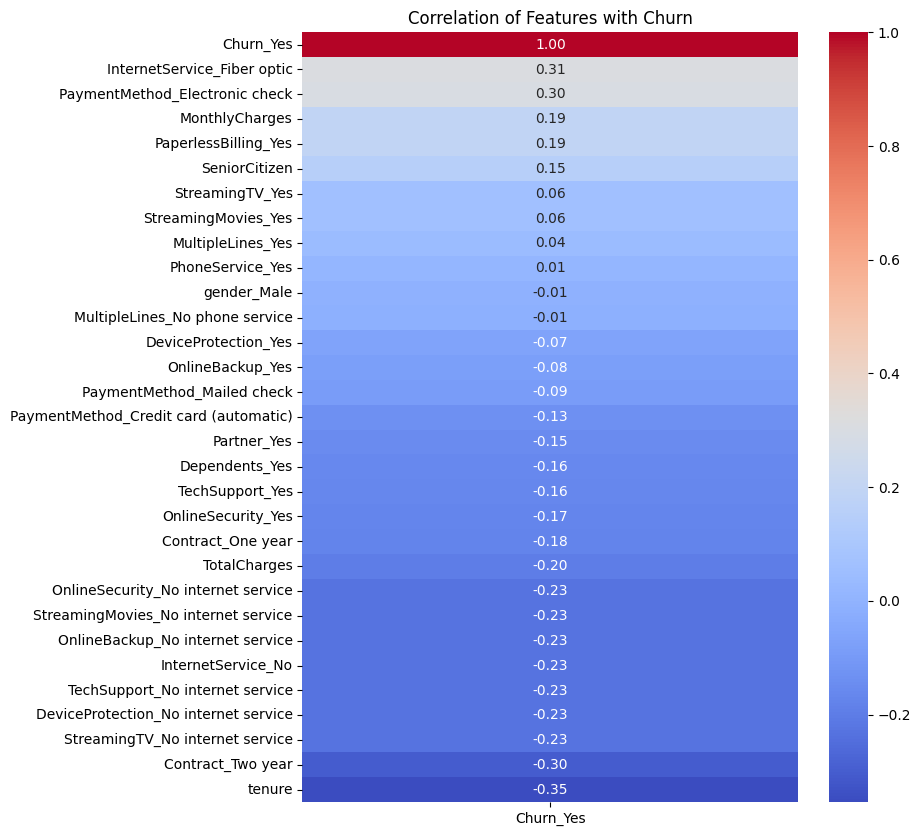

In [15]:
# Compute correlation matrix
correlations = telecom_cust_dummies.corr()

# Select only the 'Churn_Yes' column from the correlations DataFrame
churn_correlations = correlations[['Churn_Yes']].sort_values(by='Churn_Yes', ascending=False)

# Create a heatmap
plt.figure(figsize=(8, 10))
sns.heatmap(churn_correlations, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation of Features with Churn')
plt.yticks(rotation=0)
plt.show()

### Interpret correlations
- **Strong positive correlation > 0.15**, with Churn_yes: from 'Churn_Yes' all the way down to 'SeniorCitizen' (both included), indicate that customers with these charactoristics are more likely to churn.
- **Strong negative correlation < -0.15**, from 'Dependents_Yes' all the way down to 'tenure', customers with these charactoristics are less likely to churn.
- **-0.05 < Weak correlation < 0.05**, between 'Multiple_Yes' and 'MultipleLines_No phone service' (both included), have little linear relationship with churn.

The most influential features, both positively and negatively correlated, provide insights into potential drivers of customer churn, such as service type, payment method, contract duration, and how long a customer has been with the company.

## Histogram of the 'tenure'  column

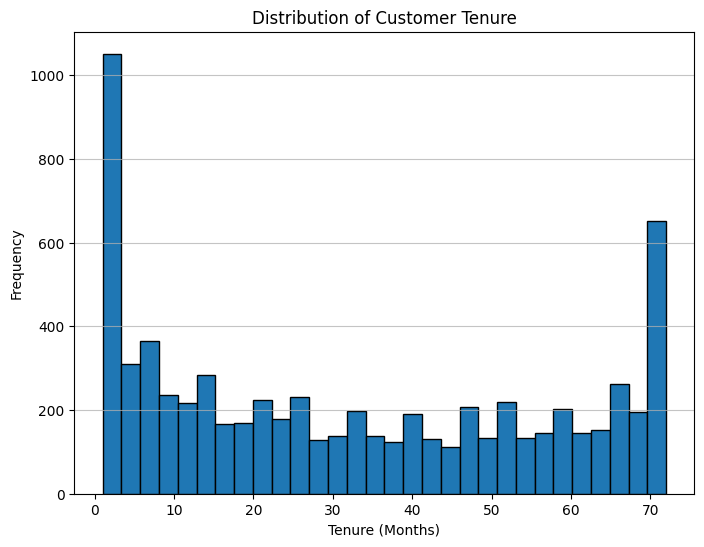

In [16]:
# Histogram on the 'tenure' column
plt.figure(figsize=(8, 6))
plt.hist(df['tenure'], bins=30, edgecolor='black')
plt.xlabel('Tenure (Months)')
plt.ylabel('Frequency')
plt.title('Distribution of Customer Tenure')
plt.grid(axis='y', alpha=0.75)
plt.show()

### Interpretation of histogram

The histogram shows the distribution of customer tenure in months. We can observe that:

* There is a large peak at the lower end of tenure, indicating a significant number of new customers (low tenure).
* The frequency of customers decreases as tenure increases, with fewer customers having longer tenures.
* There is a smaller peak at the higher end of tenure, suggesting a group of long-term, loyal customers.

This distribution indicates that the dataset is likely skewed towards newer customers, which is important to consider when building churn prediction models.

## Scatter plot
MonthlyCharges vs TotalCharges

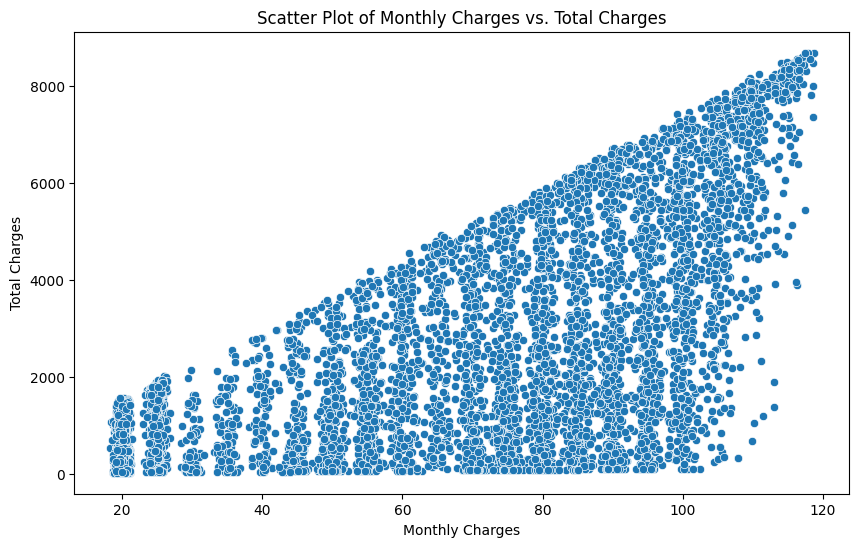

In [17]:
# Scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x='MonthlyCharges', y='TotalCharges', data=df)
plt.xlabel('Monthly Charges')
plt.ylabel('Total Charges')
plt.title('Scatter Plot of Monthly Charges vs. Total Charges')
plt.grid(False)
plt.show()

### Interpretation of scatter plot

The scatter plot visualizes the relationship between `MonthlyCharges` and `TotalCharges`. We can observe:

* A strong positive linear relationship between `MonthlyCharges` and `TotalCharges`. As monthly charges increase, total charges also tend to increase.
* The points form a scattered pattern, indicating that while there's a general trend, there is also variability.
* Some points with high monthly charges have low total charges, suggesting these are likely newer customers who haven't accumulated high total charges yet.
* Conversely, some points with low monthly charges have high total charges, indicating these are likely long-term customers with lower monthly plans.

This plot helps understand the relationship between these two important financial features and how they relate to customer tenure.

## Box plot
tenure vs churned/non-churned

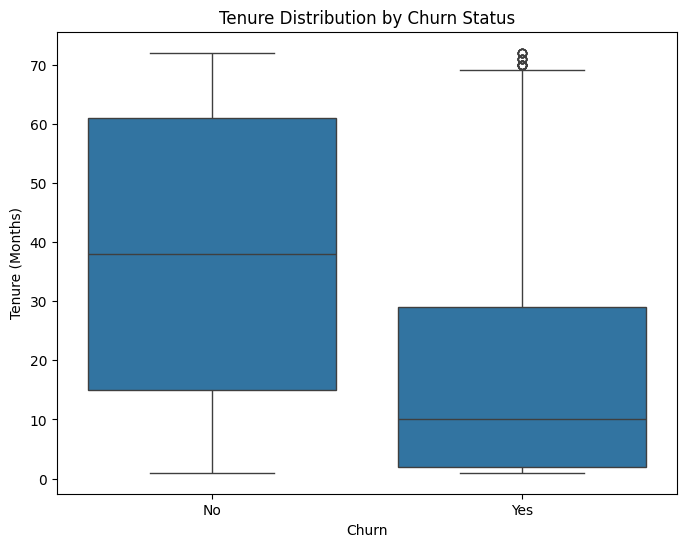

In [18]:
# Visualize box plot
plt.figure(figsize=(8, 6))
sns.boxplot(x='Churn', y='tenure', data=df)
plt.xlabel('Churn')
plt.ylabel('Tenure (Months)')
plt.title('Tenure Distribution by Churn Status')
plt.show()

### Interpretation of box plot

The box plot shows the distribution of customer tenure for customers who churned ('Yes') and those who did not churn ('No').

* **Churn = Yes:** The box for churned customers is lower and more compressed, indicating that customers who churn tend to have shorter tenures. The median tenure for churned customers is significantly lower than for non-churned customers.
* **Churn = No:** The box for non-churned customers is higher and more spread out, suggesting that customers who do not churn have longer and more varied tenures.

This visualization clearly highlights that `tenure` is a strong indicator of churn, with newer customers being more likely to churn.

# Preparation for ML training
Separate the features (X) and the target variable (y) from the `telecom_cust_dummies` DataFrame.


In [19]:
# Separate features (X) and target variable (y)
X = telecom_cust_dummies.drop('Churn_Yes', axis=1)
y = telecom_cust_dummies['Churn_Yes']

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (7032, 30)
Shape of y: (7032,)


## Scale features
Apply Min-Max scaling to scale all features to a range of 0 to 1.


In [20]:
# Create a scaler
scaler = MinMaxScaler()
X = scaler.fit_transform(X)
X = pd.DataFrame(X, columns=telecom_cust_dummies.drop('Churn_Yes', axis=1).columns)

## Split data
Split the scaled feature DataFrame X and the target Series y into training and testing sets using train_test_split. Set the test_size to 0.25 and random_state to 42 for reproducibility. Assign the results to X_train, X_test, y_train, and y_test respectively. Print the shapes of the resulting training and testing sets to verify the split was successful.



In [21]:
# Random state
r = 42

# Split into training and testing sets, 75/25 ration
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=r)

# Display results of shapes
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (5274, 30)
Shape of X_test: (1758, 30)
Shape of y_train: (5274,)
Shape of y_test: (1758,)


## Summary:

*   The features (X) and target variable (y) were successfully separated from the original DataFrame.
*   Min-Max scaling was successfully applied to all features in X, scaling them to a range of 0 to 1.
*   The scaled data was split into training and testing sets using a 75/25 ratio, resulting in the following shapes:
    *   `X_train`: (5274, 30)
    *   `X_test`: (1758, 30)
    *   `y_train`: (5274,)
    *   `y_test`: (1758,)


# Logistic Regression model
Initialize and train a logistic regression model on the training data, make predictions on the test data, and calculate and print the accuracy score of the model.

## Create and Fit model


In [22]:
# Initialize and fit the model on the training set
lr_model = LogisticRegression(random_state=r)
lr_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


## Make predictions


In [23]:
# Use the trained model to make predictions on the test set
y_pred_lr = lr_model.predict(X_test)

# Display results
print(y_pred_lr)

[False False  True ... False False False]


## Evaluate model accuracy

Calculate and print the accuracy score of the logistic regression model.

In [24]:
# Calculate and display the accuracy for the model
accuracy_lr = accuracy_score(y_test, y_pred_lr)
print(f"Accuracy Score (logistic regression): {accuracy_lr}")

Accuracy Score (logistic regression): 0.7912400455062572


## Confusion matrix

Calculate and visualize the confusion matrix for the logistic regression model using `y_test` and `y_pred`.


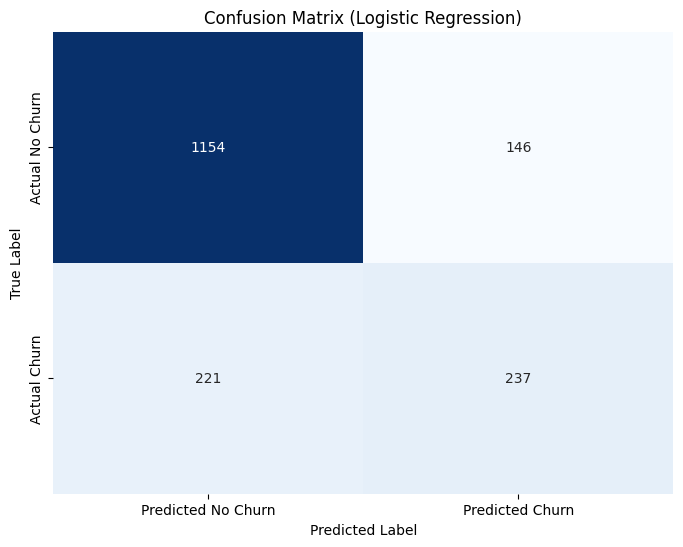

In [25]:
# Calculate confusion matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted No Churn', 'Predicted Churn'],
            yticklabels=['Actual No Churn', 'Actual Churn'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Logistic Regression)')
plt.show()

## Precision and recall


In [26]:

# Compute and display the precision and recall scores for the model
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
print(f"Logistic Regression\nPrecision : {precision_lr}")
print(f"Recall: {recall_lr}")

Logistic Regression
Precision : 0.618798955613577
Recall: 0.517467248908297


## Data Analysis Key Findings

-   The confusion matrix shows 1154 True Negatives, 146 False Positives, 221 False Negatives, and 237 True Positives.
-   The precision is approximately 61.9%, and the recall is approximately 51.7%.

# Random Forest model

Create a `RandomForestClassifier` instance with the specified hyperparameters: `n_estimators=2000`, `oob_score=True`, `max_features='sqrt'`, `max_leaf_nodes=50`, and `bootstrap=True`. Set `random_state` for reproducibility.


## Create and Fit model

Fit the Random Forest model on the training data.


In [27]:
# n_estimators
ne = 2000

# max_leaf_nodes
mln = 50

# Create and fit random forest classifier model
rf_model = RandomForestClassifier(n_estimators=ne,
                                  oob_score=True,
                                  max_features='sqrt',
                                  max_leaf_nodes=mln,
                                  bootstrap=True,
                                  random_state=r
                                  )
rf_model.fit(X_train, y_train)

,n_estimators,2000
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,50
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,True


## Make predictions

Make predictions on the test data (`X_test`).


In [28]:
# Make and display predictions on the test set
y_pred_rf = rf_model.predict(X_test)
y_pred_rf

array([False, False,  True, ..., False,  True, False], shape=(1758,))

## Evaluate model accuracy

Calculate and print the accuracy score of the Random Forest model using `y_test` and the predictions `y_pred_rf`.


In [29]:
# Compute and display accuracy score
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Test Set Accuracy Score: {accuracy_rf}")

Test Set Accuracy Score: 0.7935153583617748


## Confusion matrix

Visualize the confusion matrix for the random forest model as a heatmap.

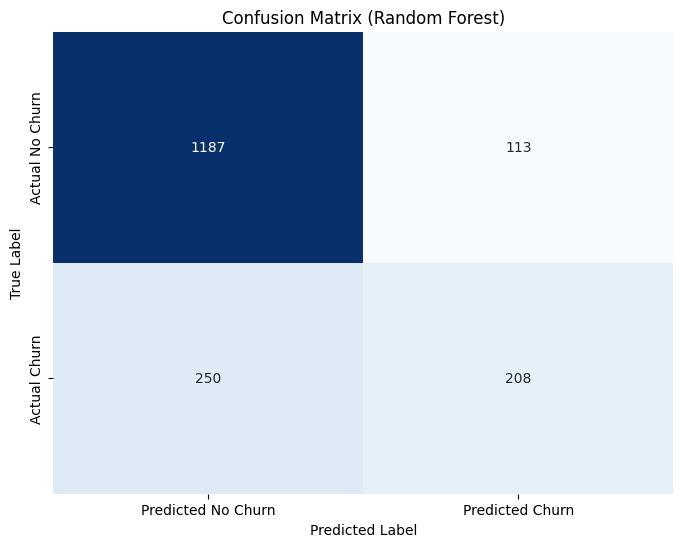

In [30]:
# Calculate and plot confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted No Churn', 'Predicted Churn'],
            yticklabels=['Actual No Churn', 'Actual Churn'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Random Forest)')
plt.show()

## Precision and recall

Compute the precision and recall scores for the random forest model using `y_test` and `y_pred_rf`.


In [31]:
# Compute and display precision and recall scores for the model
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)

print(f"Random Forest\nPrecision : {precision_rf}")
print(f"Recall: {recall_rf}")

Random Forest
Precision : 0.6479750778816199
Recall: 0.45414847161572053


## Data Analysis Key Findings

*   The confusion matrix shows 1187 True Negatives, 113 False Positives, 250 False Negatives, and 208 True Positives.
*   The precision for the **random forest** model is approximately 64.8%, and the recall is approximately 45.4%.

## Evaluate model (OOB score)

Print the Out-of-Bag (OOB) accuracy score of the trained Random Forest model.


In [32]:
# Display Out-of-Bag (OOB) score for the model
print(f"OOB Accuracy Score: {rf_model.oob_score_}")
print(f'Estimate of the error rate on unseen data: {1 - rf_model.oob_score_}')

OOB Accuracy Score: 0.807356844899507
Estimate of the error rate on unseen data: 0.192643155100493


The difference between 1 and the OOB score (1 - rf_model.oob_score_) gives an estimate of the error rate on unseen data, which is approximately 19.2%

Comparing the OOB score (appr. 80%.7) to the test set accuracy of model (appr. 79%), we can see that they are quite close, suggesting that the model is generalizing reasonably well to unseen data and is not severely overfitting.

# Enhanced model evaluation

## Classification Report

In [33]:
print('Logistic Regression Classification report:')
print(classification_report(y_test, y_pred_lr))
print('Random Forest Classification report:')
print(classification_report(y_test, y_pred_rf))

Logistic Regression Classification report:
              precision    recall  f1-score   support

       False       0.84      0.89      0.86      1300
        True       0.62      0.52      0.56       458

    accuracy                           0.79      1758
   macro avg       0.73      0.70      0.71      1758
weighted avg       0.78      0.79      0.78      1758

Random Forest Classification report:
              precision    recall  f1-score   support

       False       0.83      0.91      0.87      1300
        True       0.65      0.45      0.53       458

    accuracy                           0.79      1758
   macro avg       0.74      0.68      0.70      1758
weighted avg       0.78      0.79      0.78      1758



## Area Under the Curve (AUC)

Compare the AUC for both models


In [34]:
# Compute AUC for Logistic Regression
auc_lr = roc_auc_score(y_test, lr_model.predict_proba(X_test)[:, 1])
print(f"AUC Score (Logistic Regression): {auc_lr}")

# Compute AUC for Random Forest
auc_rf = roc_auc_score(y_test, rf_model.predict_proba(X_test)[:, 1])
print(f"AUC Score (Random Forest): {auc_rf}")

AUC Score (Logistic Regression): 0.8341501511588848
AUC Score (Random Forest): 0.8331373866308364


# Summary of Comparison:

- **Overall Accuracy**: Both models have very similar overall accuracy scores, with the Random Forest model being slightly higher.
- **Precision (Churn=Yes)**: The Random Forest model shows slightly higher precision, meaning when it predicts a customer will churn, it is more likely to be correct. This results in fewer false positives.
- **Recall (Churn=Yes)**: The Logistic Regression model demonstrates higher recall, indicating it is better at identifying actual churned customers. This means fewer false negatives.
- **AUC**: Both models have very similar and good AUC scores, suggesting they are both capable of distinguishing between churned and non-churned customers. The Logistic Regression model has a marginally higher AUC.

**Which model is more suitable?**

The choice between the two models depends on the specific business objective.

*   If the priority is to **minimize the cost of false positives** (e.g., avoiding offering retention incentives to customers who wouldn't have churned anyway), the **Random Forest model** might be more suitable due to its higher precision.
*   If the priority is to **identify as many churning customers as possible** (e.g., to proactively reach out to them), the **Logistic Regression model** might be more suitable due to its higher recall.

In many churn prediction scenarios, identifying as many potential churners as possible is crucial, even if it means a higher number of false positives. Therefore, based on the slightly higher recall for the 'Yes' class and a marginally higher AUC, the **Logistic Regression model might be considered slightly more suitable** for this specific task, assuming the goal is to capture a larger portion of actual churners. However, the Random Forest model's higher precision could also be valuable if the cost of retention efforts is high.

Ultimately, the "best" model depends on the specific business context and the relative costs of false positives and false negatives.

